In [15]:
import torch
import torch.nn.functional as F
import requests
import os
import random
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import tqdm
from tqdm.auto import tqdm
import plt

In [2]:
path = "input.txt"
if not os.path.exists(path):
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    resp = requests.get(url, stream=True)
    total = int(resp.headers.get("Content-Length", 0))
    with open(path, "wb") as f:
        bar = tqdm(total=total, unit="B", unit_scale=True, desc="input.txt")
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
        bar.close()

with open(path) as f:
    text = f.read()

print(len(text))
print(text[:500])

1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


In [ ]:
if (device := torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")):
    print(f"Using device: {device}")

block_size = 8
epochs = 200
lr = 0.001
embd = 32
head = 100
batch=8192

Using device: cuda


In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
print(chars)
def stoi(x):
    return chars.index(x) if isinstance(x, str) else chars[x]
_stoi = {c: i for i, c in enumerate(chars)}
def itos(x):
    return _stoi[x] if isinstance(x, str) else chars[x]

print("itos:", itos(1), itos(2), itos(3), itos(0), "\n")
print("stoi:", stoi('.'), stoi('a'), stoi('b'), stoi('c'), "/n")

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
itos:   ! $ 
 

stoi: 8 39 40 41 /n


In [5]:
def build_dataset(data):
    X, Y = [], []
    for i in range(len(data) - block_size):
        X.append(data[i : i + block_size])
        Y.append(data[i+1 : i + block_size + 1])
    X = torch.stack(X)
    Y = torch.stack(Y)
    return X, Y

In [6]:
data = torch.tensor([stoi(c) for c in text])
X, Y = build_dataset(data)
n = X.shape[0]
Xtr, Ytr = X[:int(n*0.9)], Y[:int(n*0.9)]
Xdev, Ydev = X[int(n*0.9):], Y[int(n*0.9):]
Xtr, Ytr = [x.to(device) for x in (Xtr, Ytr)]
Xdev, Ydev = [x.to(device) for x in (Xdev, Ydev)]
print(X.shape, Y.shape)
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)

torch.Size([1115386, 8]) torch.Size([1115386, 8])
torch.Size([1003847, 8]) torch.Size([1003847, 8])
torch.Size([111539, 8]) torch.Size([111539, 8])


In [7]:
trainds = torch.utils.data.TensorDataset(Xtr.cpu(), Ytr.cpu())
traindl = DataLoader(
    dataset=trainds,
    batch_size=batch,
    pin_memory=False,
    shuffle=True,
    num_workers=16,
    prefetch_factor=16
)

In [8]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(embd, head_size, bias=False)
        self.query = nn.Linear(embd, head_size, bias=False)
        self.value = nn.Linear(embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5 #BTC @ BCT => BTT
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        out = wei @ v
        return out
        

In [9]:
class multihead(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])

    def forward(self, x):
        return torch.cat([h(x) for h in self.heads], dim=-1)

In [ ]:
class feedForward(nn.Module):
    def __init__(self, embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embd, embd),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
class atten(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embd)
        self.position_embedding = nn.Embedding(block_size, embd)
        # self.sa_head = Head(embd)
        self.sa_head = multihead(4, embd//4)
        self.lm = nn.Linear(embd, vocab_size)
        self.ffw = feedForward(embd)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.sa_head(x)
        x = self.ffw(x)
        return self.lm(x)
        # if(targets == None):
        #     loss = None
        # else:
        #     B,T,C = logits.shape
        #     logits = logits.view(B*T, C)
        #     targets = targets.view(B*T)
        #     loss = F.cross_entropy(logits, targets)
            

In [11]:
model = atten().to(device)
# model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma = 0.99995)

In [12]:
model.train()
pbar = tqdm(range(epochs), desc="train")
t_loss = []
for e in pbar:
    e_loss = []
    for Xb, Yb in traindl:
        Xb, Yb = Xb.to(device), Yb.to(device)
        logits = model(Xb)
        loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
        e_loss.append(loss.item())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        scheduler.step()
    t_loss.append(sum(e_loss) / len(e_loss))
    pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")
    # if e % 10 == 0:
    #     print(e, loss.item(), scheduler.get_last_lr()[0])

train:  34%|███▍      | 204/600 [04:06<07:57,  1.21s/it, loss=2.0371, lr=2.85e-04]


KeyboardInterrupt: 

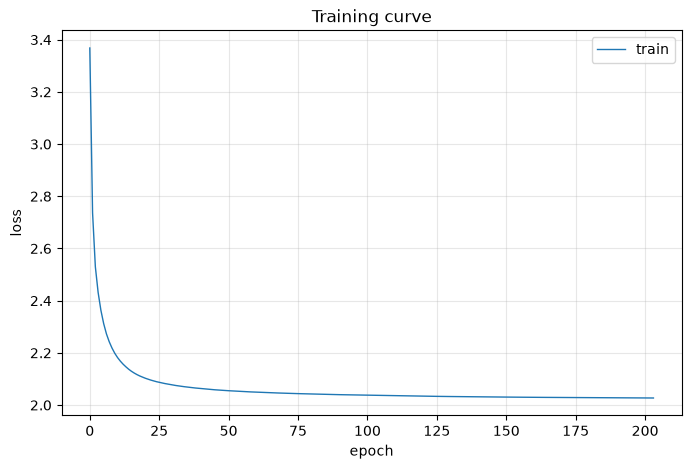

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(len(t_loss)), t_loss, label='train', linewidth=1)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Training curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
model.eval()
with torch.no_grad():
    ix = torch.randint(0, Xtr.shape[0], (Xtr.shape[0],), device=device)
    Xb, Yb = Xtr[ix], Ytr[ix]
    logits = model(Xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
    print("train loss:", loss.item())

    ix = torch.randint(0, Xdev.shape[0], (Xdev.shape[0],), device=device)
    Xb, Yb = Xdev[ix], Ydev[ix]
    logits = model(Xb)
    loss = F.cross_entropy(logits.view(-1, vocab_size), Yb.view(-1))
    print("dev loss:", loss.item())


train loss: 2.026796340942383
dev loss: 2.14918851852417


In [18]:
model.eval()
for i in range(10):
    out = []
    context = [0] * block_size
    for _ in range(500):
        logits = model(torch.tensor([context], device=device))
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(itos(ix))
    print(''.join(out))


I grazedd Mot Clies tur's hee it blo, going ther lea siscer say fresh.

VIS: looquary it
that would I:
Gamurs noth frow hing.

Ist them-my begaitt thead the heearmbege bight min ks thom your crom you sto of be the!
iblet leeen's you frear hat meswear bidy as am vand his fend.
Why thy I
-
Witen hist soblul the give. OF YORK:
Mard sto way in heenth nothe thou theak thou, petch end; I sakin. O, it
In in amy Dep it is ound pay
As briord;
Than is ways:
If at a frown sp I leate no, buch heel sto and 
Nurch tress dow st my me and deeld hossouch with
Ay,
While'twit's kind din like so my thein sut lieoiend seirtencureald lans, inst,' they them met hand that the that thom uncture, tou me swordsedof van in yourd Get shis lamne! louish dinnow, be od is this nobunt hidsed
Af
Wariell!
Heraugh for greforiowen but;
And'st, Iting soffe the by thate
A wory wits!
I himes, throth my to masshat mist
My soid wereatles: might.

LANTUS:
O, far with wornd coure I shoon in do nouch and
I, as oul lostind whe of